https://artint.info/3e/html/ArtInt3e.html

# Introduction

**Agent** - something that acts in an environment. Worms, dogs, thermostats, airplanes, robots, humans, companies, countries. 

**Intelligence** can include
- actions appropriate for circumstances and goals
- actions take into account short- and long-term consequences
- learning from experience
- flexible to changing environments and goals. 

**Computational agent** has decisions which can be broken down into primitive operations that can be implemented in a physical device/computer. 

**Artificial intelligence** is the field studying the synthesis and development of *computational agents that act intelligently*. 

# Reasoning and Planning with Certainty 

## Searching for Solutions

### State space models

A **state** is a data structure representing a possible configuration of the world (agent and environment). The **state space** of a problem is the set of all possible states. 

**Actions** change the state of the world. This can be considered as a directed graph with actions represented by edges from one node (state) to another. 

We can also call them nodes and **arcs**. A **path** is a sequence of nodes connected by arcs; in practise often represented by a sequence of arcs. The **length** of a path is the number of nodes - 1, since you don't count the starting node. An arc/path may have a **cost**. Given a set of **starting nodes** and **goal nodes**, a **solution** is a path from *a* starting node to *a* goal node. 

In an **explicit graph** the entire graph (nodes and edges) is in the memory in an adjacency list/matrix. In an **implicit graph** the entire graph is not stored; instead there is some procedure `outgoing_arcs` which, given a node, returns the set of arcs connecting it to other nodes. 

The complexity of algorithms can be measured by the *depth* of goal nodes and the *branching factor* (number of outgoing arcs). 

### Generic graph search

A graph can be unfolded into a **search tree** with the root being the starting state and each node representing a unique path from the starting state. Multiple search trees make a **search forest**. 

A **generic graph search** incrementally explores paths from start nodes, maintaining a **frontier** or open list of paths under consideration, which is updated by expanding paths and adding their successors, until a goal is found. The order in which paths are added to and removed from the frontier defines the **search strategy** - how the graph is unfolded into a search tree/forest. 

```
Input: graph, goal nodes, procedure goal(n) testing if n is a goal node. 

frontier = {start node s}

while frontier is not empty:
    select and remove a path p from frontier
    if goal(p[-1]):
        return p
    for every neighbour of p[-1]:
        add p + neighbour to frontier
```

### DFS

One such strategy is **DFS**. The frontier here must be a stack - last in, first out. In Python we can implement this as a stack; the last element is selected/popped, all the paths from it appended to the stack, and the next element only popped when all possible paths have been explored. 

DFS is 
- not guaranteed to find a solution with the fewest arcs. 
- guaranteed to find a solution, if there is one, given the graph is finite with no cycles. 

With a depth *d* and branching factor *b*, the time complexity will be $O(b^d)$ (the size of the tree) and the space complexity will be $O(d\times b)$. 

### BFS

Now the frontier will be a queue object (first in, first out). 

BFS is
- guaranteed to find a solution with the fewest arcs. 
- guaranteed to find a solution, if there is one, even if the graph is infinite and even if it has cycles. 

The time complexity is again $O(b^d)$ whereas the space complexity is also unfortunately $O(b^d)$ (could explore entire tree before finding solution). 

### LCFS (Lowest-cost-first search)

The cost of a path is the sum of the costs of its arcs. LCFS selects a path on the frontier with the *lowest cost*, to find an optimal least-cost path to a goal node. 

The frontier is a queue (FIFO) ordered by cost, i.e. a **priority queue**:
1. Element with higher priority/lower cost always removed first
2. Elements with same priority should be sorted by enqueue time
Can use `heapq` in Python. 

To summairse, LCFS explores *increasing cost contours*. It is guaranteed to find an optimal solution, but explores options in every direction, which can make it inefficient. 

#### Pruning

This is a way to avoid infinite search trees when cycles are present and to make computation more efficient. The idea is to avoid re-expanding already expanded nodes. 

(By expanded nodes we mean the end node of a path which has been returned by the frontier (i.e. -scg or something like that). Expanding a node generates zero or more successor paths.)

To implement this, the frontier keeps a set of already expanded nodes. A path is added only if its end node is not in the expanded set. 

### Heuristic search (Best-first, A*)

A way to make search more efficient is to use the knowledge you already have relating to your goal to guide your search via some **heuristic function** `h(n)`, which *estimates* the cost from a node to a goal. This `h` needs to be efficient to compute, must be non-negative for every node, and must be less than or equal to the cost of an optimal path from $n$ to the goal node. 

An example could be the Euclidian distance from $n$ to the goal node, if the nodes are points on a plane. If nodes are locations in a maze, `h(n)` could be Manhattan distance. 

#### Best-first search

In best-first search, you select the path with the lowest value for `h(n)`. It is a greedy strategy, treating the frontier as a priority queue ordered by `h`. In many instances, it can find a solution faster than LCFS; however, it does not guarantee finding an optimal solution.

#### A* search

The idea is to be less wasteful than LCFS but less greedy than best-first search. The cost of paths is estimated as if they could reach a goal node in the best possible way: $f(p)=cost(p)+h(n)$, i.e. cost is estimated as actual cost from start to $n$, and then cost from $n$ to the goal is estimated using the heuristic function. 

This method is guaranteed to find an optimal solution so long as
- one exists;
- there is no pruning; and
- the heuristic function is *admissible*, i.e. follows the constraints defined earlier (non-negative and less than or equal to the cost of an optimal path to the goal from $n$). 

This is because:
- Suppose the first path to the goal node removed from the frontier by A* search, $p$, is *not* the optimal path. 
- Then there must be a path $p'$ on the frontier such that one of its successor paths leads to the goal node and has a lower overall cost than $p$. 
- Since $p$ was removed before $p'$, $f(p)\leq f(p')\implies cost(p)+h(p)\leq cost(p')+h(p')\implies cost(p)\leq cost(p')+h(p')$. 
- But for any successor of $p'$ leading to a goal node, $c$, $cost(p'c)=cost(p')+cost(c)\geq cost(p')+h(p')$, since $h$ is admissible. 
- Thus, $cost(p)\leq cost(p')+cost(c)=cost(p'c)$, leading to a contradiction. 

One remaining niggle of this method is that we can't use pruning. The reason being that it doesn't guarantee that the paths first discovered are the cheapest - you might have to explore multiple paths to an intermediate node before finding the optimal one, because your heuristic might be inaccurate. The bottom graph gives an example of a case where this might happen. Here $h(a)$ is too low compared to $h(b)$, making $a$ mistakenly look better. 
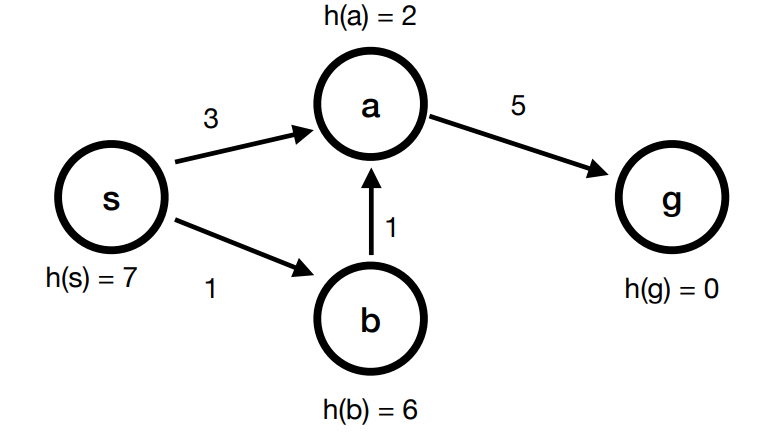

To allow pruning, and greater efficiency, we can add an extra condition to `h`: it must be **monotone** or **consistent**. This means that for every two nodes $n$, $n'$ where $n'$ is reachable from $n$, $h(n)\leq cost(n,n')+h(n')$; that is to say, the heuristic's estimate for getting from $n$ to $n'$ to the goal cannot be less than that for getting from $n$ to the goal. In other words, the real cost part of an intermediate path should always *meet or exceed the reduction in heuristic*, compared to not taking that path. 

Then, 
\begin{align*}
f(n')&=cost(s,n')+h(n')\\
&=cost(s,n)+cost(n,n')+h(n')\\
&\geq cost(s,n)+h(n)\\
&=f(n)
\end{align*}

i.e., $f$ is non-decreasing along any path (since $n'$ is a successor to $n$). 

if the monotonicity requirement is met, A* will yield optimal results with pruning, too. 

#### Choosing a heuristic

A common approach is to consider a simpler version of the problem. It is difficult to find an admissible heuristic, but luckily, admissible heuristics are usually also consistent. Inadmissible heuristics are OK  if you don't mind sacrificing optimality. 

#### Dominance Relation

A heuristic is **dominant** over another heuristic (hehe) if for all nodes $n$, $h_a(n)\geq h_c(n)$. Then $h_a$ is 'better' than $h_c$; since any valid heuristic is guaranteed to be less than the actual cost, $h_a$ will be closer to the exact cost, meaning more efficient pruning. 

This allows a *hierarchy* of heuristics to be created, as visualised below. 

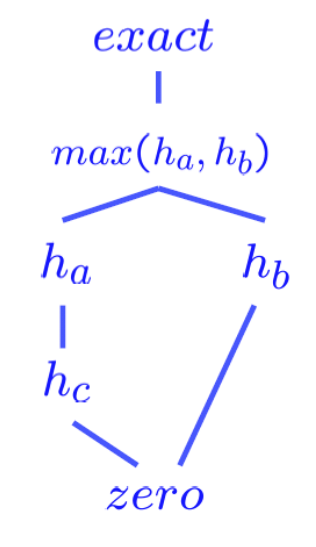

Then for some partially equivalent $h_a,h_b$, we can form a new heuristics $max(h_a,h_b)$ which is guaranteed to dominate both of them - and to be admissible. 

## Propositional Logic

### Introduction & Propositional Calculus

A **proposition** is a sentence written in some language, which has truth value - i.e. it can be true or false - in some world. It is built from **atomic propositions** or **atoms** and **logical connectives**, and therefore can also be built from logical connectives and simpler propositions. 

An **atom** can be defined depending on your language, but we will define it as a sequence of letters, digits, and underscores beginning with a lowercase letter. 

A **proposition** can be an atomic proposition, or a compound proposition of the form

| Proposition | Read as | Meaning |
|---|---|---|
| $\neg p$ | "not $p$" | negation of $p$ |
| $p \land q$ | "$p$ and $q$" | conjunction of $p$ and $q$ |
| $p \lor q$ | "$p$ or $q$" | disjunction of $p$ and $q$ |
| $p \rightarrow q$ | "$p$ implies $q$" | implication of $q$ from $p$ |
| $p \leftarrow q$ | "$p$ if $q$" | implication of $p$ from $q$ |
| $p \leftrightarrow q$ | "$p$ if and only if $q$" | equivalence of $p$ and $q$ |
| $p \oplus q$ | "$p$ XOR $q$" | exclusive-or of $p$ and $q$ |

**Semantics** means a way to define the meaning of sentences in a language. In the propositional calculus - the language we have been describing so far - we use **interpretations**. These are functions $\pi$ mapping atoms to $true$ or $false$. Then the truth of a compound proposition can be determined using the properties of its logical connectives. 

A **knowledge base** is the set of propositions stated to be true, called **axioms**. A **model** with a knowledge base $KB$ is an interpretation in which all the statements in $KB$ are true. 

$g$ is a **logical consequence** of $KB$ if $g$ logically follows from $KB$ in every model of $KB$; then $KB\models g$.

This is useful because if you have a particular world to characterise, a **knowledge base designer** can choose that world as an **intended interpretation**, and then use the propositional calculus to answer questions about the world using a logical model of it. 

1. Choose task domain
2. Choose atoms in the computer, denoting propositions, which have meanings to the designer w.r.t. the intended interpretation
3. Choose some true propositions - i.e. **axiomise the domain**
4. Ask questions about other propositions, and interpret w.r.t. intended interpretation



### Propositional definite clauses, proofs

The language of **propositional definite clauses** is a subset of propositional calculus that does not allow uncertainty or ambiguity.

A **definite clause** is of the form $h\leftarrow a_1\land ...\land a_m$, where the atom $h$ is the **head** of the clause, and each $a_i$ is an atom. If the RHS is empty, it is called an **atomic clause** or a **fact**; otherwise, it is called a **rule**, with the $a$ being the **body**. A **knowledge base**, then, is a set of definite clauses. 

A DC is false in interpretation $I$ if the body is true but the head is false; otherwise, the DC is true in $I$. 

A **query** is the question: 'Is this proposition a logical consequence of the knowledge base?', notated as: ask $b$, where $b$ is some body (i.e. an atomic proposition, or a series of atomic propositions connected with 'and'). 

A **proof** is a demonstration that a proposition logically follows from a knowledge base. $KB\vdash g$ indicates that there exists a proof procedure for which $g$ can be derived from knowledge base $KB$; this procedure is **sound** if $KB\vdash g\implies KB\models g$ (i.e. result of a sound proof procedure is always correct) and **complete** if $KB\models g \implies KB \vdash g$ (i.e. a complete proof procedure can produce all results). 

### Bottom-up proof procedure

In a *bottom-up proof prodecure*, you use the fact that if $h\leftarrow b_1\land ... \land b_m$ and each $b_i$ has been derived, then $h$ can be derived. The following procedure allows you to use this bottom-up proof procedure by starting with the knowledge base and working up to find all the clauses that can be derived from it. 

$C  := \{\};$
```
repeat
    select clause h <- b_1 ^ ... ^b_m in KB such that
        b_i in C for all i, and
        h not in C
    C := C U {h}
until no more clauses can be selected. 
```



### Top-down proof procedure

In a *top-down proof procedure*, you search backwards from a query to determine whether it is a logical consequence of $KB$. This is also called **propositional definite clause resolution** or **SLD resolution**, where SL = Selecting an atom using a Linear strategy and D = Definite clauses. It uses an **answer clause** of the form $yes\leftarrow a_1\land ... \land a_m$ to the query $\text{ask } a_1\land ... \land a_m$. This answer clause is refined using the following procedure:

- Select a **subgoal** $a_i$. 
- If it exists, select a definite clause in KB with $a_i$ as the head. 
- Find the **resolvent** of the answer clause with this definite clause, which is your answer clause, but replacing $a_i$ with the body of the definite clause. 
- Repeat until you run out of options or until you get an **answer** - $yes \leftarrow$. 

An **SLD derivation** of a query from a knowledge base $KB$ is a series of answer clauses starting with the answer clause corresponding to the original query and ending at an answer. 

Becuase you can pick a number of subgoals and definite clauses as intermediate steps, just because you didn't get to an answer, doesn't mean there isn't a way to get to an answer. 

Therefore, you can create a graph based on all the possible paths, looking for a path which ends with an answer. I can traverse it with BFS (if memory doesn't matter, but the shortest path matters) or DFS (if memory matters, and the shortest path doesn't). If I suspect there are cycles, I should use BFS. 

## Predicate Logic

### Declarative Programming

In propositional logic we had propositions; now we have **predicates** and **variables**, which we will explore through the non-theoretical framework of **declarative programming** - the use of mathematical logic to describe the logic of computation without describing how it works (loops, instructions etc.). An example of this is SQL. 

### Clauses, predicates, queries, and variables

THe idea of a declarative programming language is to describe the situation of interest using a knowledge base (program) and then ask a question (query). We will look at `Datalog`, a subset of the language `Prolog` (Programming in Logic). 

Prolog statements:
- `consult(filename)` to load a file into the interpreter
- Ask question using `?-`
- To exit type `halt`

Program may look like:
```
woman(mia)
woman(jody)
woman(yolanda)
playsAirGuitar(jody)
party.
```
Then `playsAirGuitar(jody), party, woman(mia)` will all return `yes` whereas `woman(grace)` or `tattooed(jody)` would return `no`. 

It could also look like:
```
happy(yolanda). #fact
listens2music(mia). #fact
listens2music(yolanda) :- happy(yolanda). #rule
```
There are three **clauses** each marked by a full stop and two **predicates** - `happy` and `listens2music`. A rule is given by `:-` which loosely means that the right hand side implies the left hand side. As with before, the left hand side is the *head* and the RHS the *body*; the body can consist of more terms - a comma can be used for and, or a semicolon for or. 

Something with a capital letter indicates a variable; for example, we could ask the query `woman(X)`, which asks whether `X` can be assigned to any value such that `woman(X)` holds. The result will be such an assignment, e.g. `X=mia`. In Prolog, you can press the semicolon to iterate through possible values, until the possibilities are exhausted and `no` is output. 

Joining statements with a comma, again, indicates 'and' - for example `loves(marsellus, X), woman(X)`.

Variables can also be used to indicate a 'template' for certain predicates; for example `jealous(X,Y) :- loves(X,Z); loves(Y,Z)`. A variable in the head is **universally quantified**; a variable whicch only appears in the body is **existentially quantified**. That is to say, if a variable appears i

### Syntax

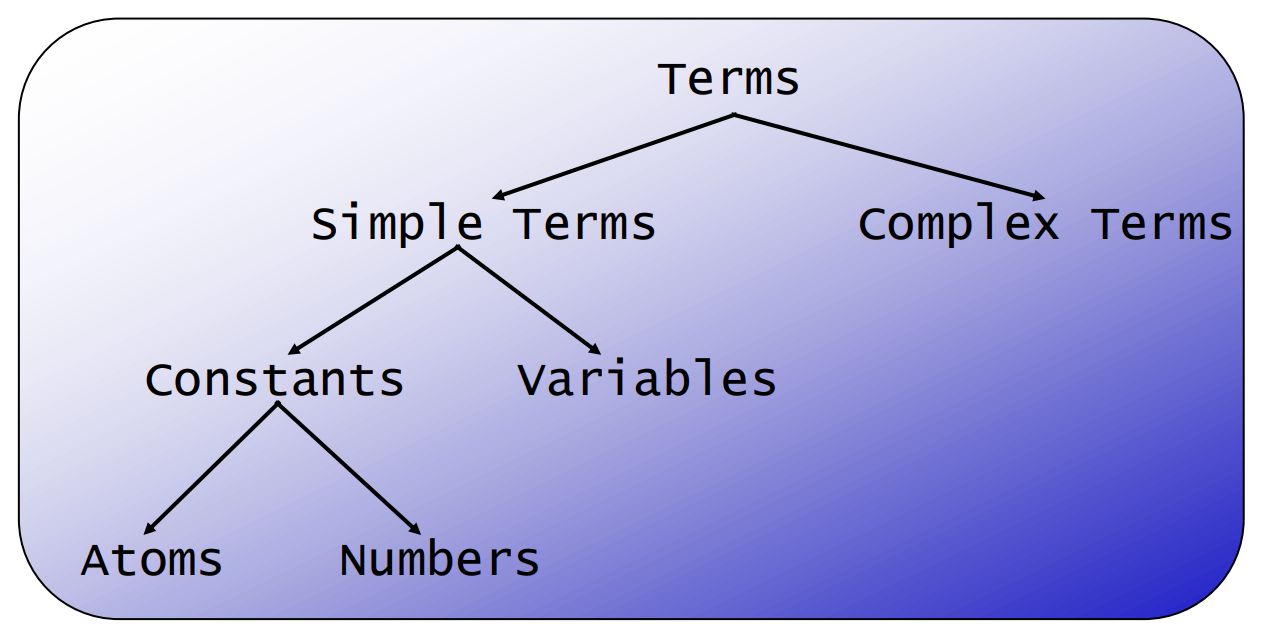

In Datalog/Prolog the simplest particles are **atoms** (a sequence of upper- and lowercase letters, digits and underscores, or an arbitrary sequence of characters enclosed in '') and **numbers** (integers and floats). There are also **variables**, which begin with an uppercase letter or an underscore. 

Then we have **complex terms**, built out of atomic **functors** (the name part of a *predicate*) with **arguments** enclosed in brackets. The number of arguments of a functor is its **arity**. If two predicates are defined with the same functor but different arity, they will be treated as two different predicates. Arity can be denoted using, for example, `woman(mia)` being `woman/1`. 

Two terms **unify** if they are the same term, or if they contain variables that can be **uniformly instantiated** (have the same values assigned to them) with terms in such a way that the resulting terms are equal. This can be explicity said using `=`. For example, `mia = mia` will give `yes`, as will `mia = X`, but `X=mia, X=vincent` will give `no`. `k(s(g), Y)=k(X,t(k))` will give `X=s(g), Y=t(k), yes`. 

### Proof search

Unification is the basis for how a predicate logic system searches a knowledge base to determine whether a query is satisfied. The way this works is that it searches a knowledge base from top to bottom using DFS, processing clauses from left to right and comparing using unification at each point. This is called **proof search**. 

For example, take the following knowledge base. 
```
f(a). 
f(b). 
g(a). 
g(b). 
h(b). 
k(X):-f(X),g(X),h(X).
```
When we ask `?-k(Y)`, it first scans through the knowledge base to find a head which unifies with the query, and finds `k(X)`. Now the new query is the body `f(X), g(X), h(X)`, much like the backwards chaining in the previous section. For the first one, we see if we can satisfy it - scanning through, we find `f(a)` and to satisfy it instantiate `X=a`. Then we go on to satisfying `g(a), h(a)`. We find that `g(a)` is a fact. However, we are not able to find a head that unifies with `h(a)`. 

Going back up, what if we assigned `X=b` instead? Then we will end up getting our solution. This backtracking allows the procedure to be sound and correct. 

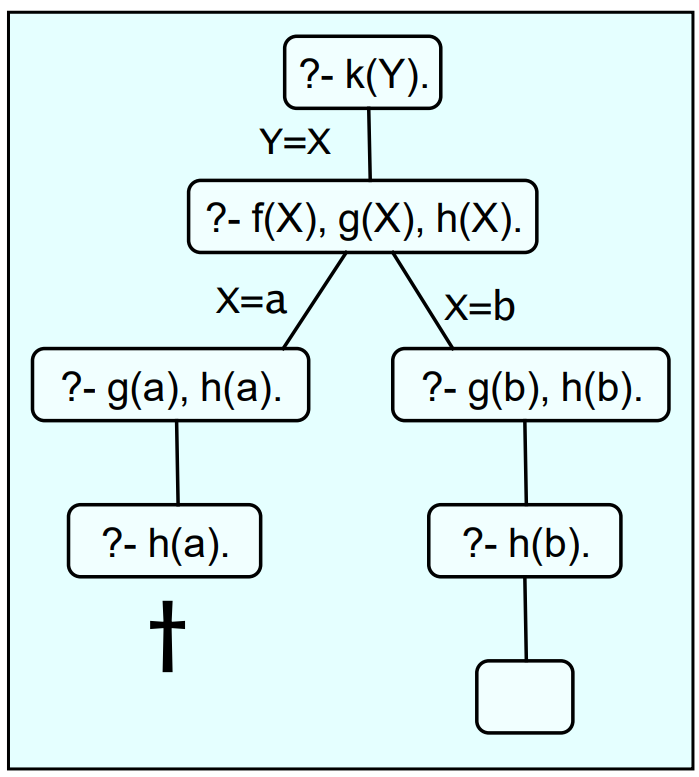

### Recursive rules

We can have recursive programming in predicate logic. For example
```
child(anna,bridget). % Anna is a child of Bridget
child(bridget,caroline).
child(caroline,donna).
child(donna,emily).
descendant(X, Y) :- child(X, Y).
descendant(X, Y) :- child(X, Z), descendant(Z, Y).
```

### Lists

We can also have a list or collection of things. These are separated by commas and enclosed by square brackets. You can have empty lists and nested lists. 

In Prolog, we can thing of a list as a head, which is the first element - an atom, and the tail, which is the rest of the elements - a list. For the list `[[], foo(z), [2, Z]]` we have a head `[]` and a tail `[foo(z), [2, Z]]`. A list may have an empty tail; if it is empty, it has neither a head nor a tail. The operator `|` can be used to decompose a list into its head and tail. For instance, `[Head|Tail]=[mia, vincent, jules, yolanda]` gives `Head=mia, Tail=[vincent, jules, yolanda], yes` - in other words, this list can be decomposed into a head and a tail called Head and Tail. 

You can also make the head into two items, so long as the list has two or more items, for instance `[X, Y|Tail]`. 

If you need to use a variable, but are not interested in what Prolog instantiates it to, you can use an underscore. For instance, `[_,X2, _,X4_|_] = [mia, vincent, marsellus, jody, yolanda]` gives `X2 = vincent, X4 = jody, yes`. 

An example of a recursive list implementation is membership of a list:
```
member(X,[X|T]).
member(X,[H|T]) :- member(X,T).
```
This could also be written as
```
member(X,[H|T]) :- X=H; member(X,T).
```
This idea of membership could be used to iterate through a list, if placed inside another predicate. 


We can also define a recursive predicate `append` whose arguments are 3 lists, giving `yes` if L3 is the result of concatenating L1 and L2. 
```
append([], L, L).
append([H|L1], L2, [H|L3]) :- append(L1, L2, L3). 
```
This removes the head of L1 and L3 piece by piece until it arrives at an empty list for L1 and (hopefully) L2 for L3. 

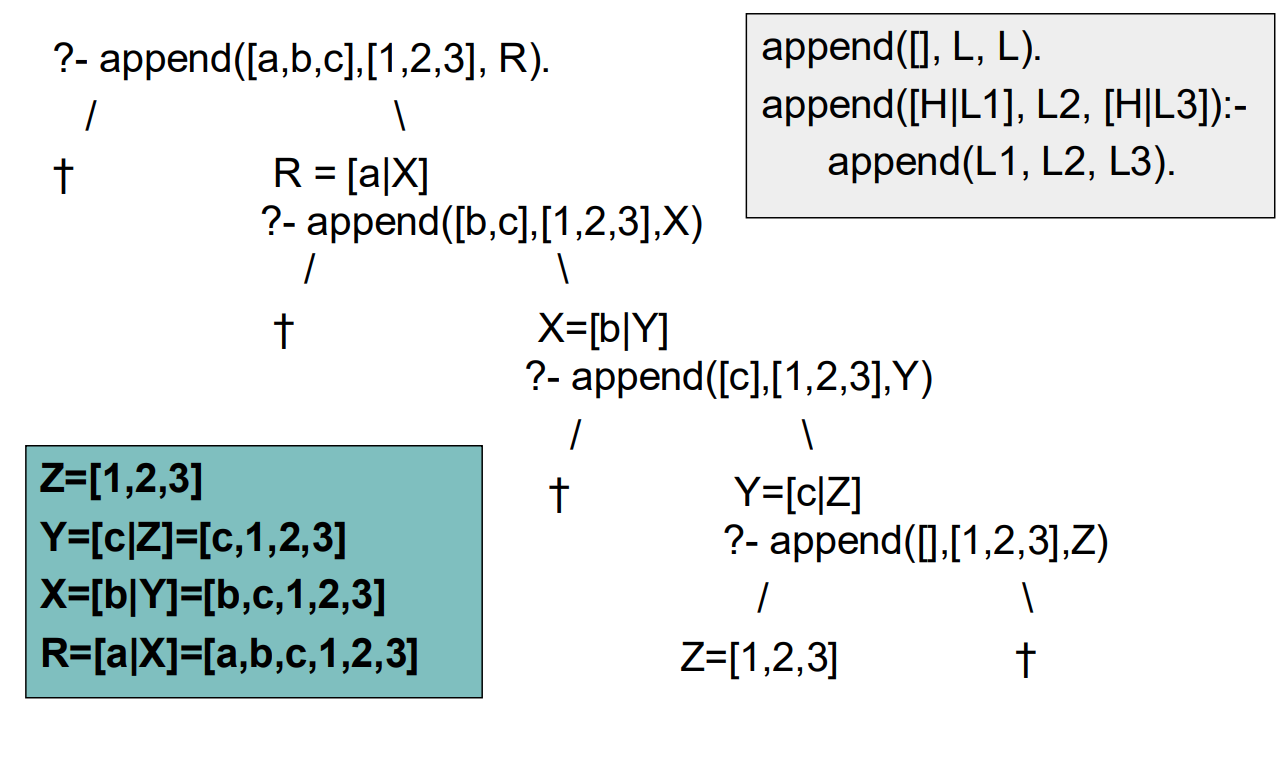
In the above example, we find the result of appending `[1,2,3]` to `[a,b,c]`. The base case does not hold, so we remove the first element of L1 and L3, giving the new query `?-append([b,c], [1,2,3], X)` where `R=[a|X]`. We repeat this until we get `?-append([], [1,2,3], Z)`. Then the base case holds, and we get that `Z=[1,2,3]`. Then `Y=[c,1,2,3]`, `X=[b,c,1,2,3]`, and `R=[a,b,c,1,2,3]`. 

## Reasoning with Constraints

### Constraint Satisfaction Problem

A **constraint satisfaction problem** is characterised by a set of **variables** $V_1,\ldots,V_n$; a set of associated **domains** (one for each variable) defining the set of values that each variable can assume, and a set of **constraints** on various subsets of the variable which specify the allowed *combinations* of values for one or more variables. 

A **total assignment** is an assignment of a value to every variable, i.e. an n-tuple from the Cartesian product of all domains; a **solution** is a total assignment satisfying all constraints. 

Examples of CSPs might be sudoku, crosswords, or N-queens; more practically, scheduling, organising assembly lines, or positioning agents in 3D space with some constraints.

Several algorithms can be used to solve CSPs - *generic algorithms* like exhaustive search, backtracking, and graph search, or *specialised algorithms* like arc consistency, domain splitting, and variable eliminiation. 

### Generate-and-test (exhaustive) algorithm

1. Generate the assignment space as the Cartesian product of the domains
2. Test each assignment against the constraints

This is exponential in the number of variables. 

### Backtracking algorithm

1. Instantiate the variables one at a time. 
2. Evaluate each constraint as soon as all variables inside it have a value. 
3. Any partial assignment that doesn't satisfy the constraints can be pruned. 

This is an improvement because if a partial assignment doesn't satisfy a constraint, you no longer explore solutions including it. 

### Graph search algorithm

1. A node is a partial assignment. 
2. The start node is the empty assignment. 
3. The neighbours of a node are assignments of not yet assigned variables, that satisfy constraints on the variables. 
4. A goal node is a total assignment satisfying all constraints. 

### Arc consistency

An instance of CSP can also be represented as a special type of graph, called a **constraint network**. There is a node for each variable + domain (oval), and for each constraint (rectangle); there is an arc from variable X to each constraint involving that variable. 

An arc $(X, r(X,Y))$ is **arc consistent** if $\forall x\in dom(X)\exists y\in dom(Y):r(X,Y)$ is satisfied. A network is arc consistent if all its arcs are such. 

If an arc is *not* arc consistent, all $x \in dom(X)$ for which there is no corresponding $y\in dom(Y)$ should be deleted from $dom(X)$ to make the arc consistent. 

Hence, by reducing the domains/search space, the problem is simplified. 

Note that iterating through all the arcs once is not enough; if the domain of some $Y$ is reduced, $(X,r(X,Y))$ needs to be revisited. 

```
for each X:
    DX = dom(X) # need to make a copy

to_do = {(X, c) for constraints c for which X in scope(c)}

while to_do is not empty:
    pop (X,c) from to_do
    new DX = {x: x in DX and there exists for all Yi also in scope(c) yi in DYi s.t. c(x, y1, ..., yn) = True}

    if new DX != DX: # if domain has been changed
        to_do = to_do U {(Z,c'): X in scope(c'), c' != c, Z in scope(c') - X}
        DX = new DX

return 
```

After this algorithm there are some possibilities:
1. One or more domains empty - no solution
2. Each domain has a single value - unique solution
3. Some domains have > 1 value, and none are empty - further search is required to find solutions. 

### Domain splitting

The way this further search can be done is through **domain splitting** (though you could also use graph search or backtracking). This is a recursive approach where domains are split and worked on independently, and the result is the union of solutions. 

```
def solve_all(CSP, domains):
    if one or more domains are empty:
        return {}
    if all domains have one element:
        return {domains}
    else:
        select variable X with domain D and |D| > 1
        partition D into D1 and D2 (e.g. half)
        return solve_all(CSP, domains with dom(X) = D1) U solve_all(CSP, domains with dom(X) = D2)
```

### Variable elimination

Another method of solving a CSP borrows from relational database theory.    